In [1]:
from google.colab import files

uploaded = files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip


In [6]:
import zipfile
import os

zip_path = "CIFPS - DATASET A.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/datasetA')

print("Extraction Complete!")

Extraction Complete!


In [7]:
import os

for root, dirs, files in os.walk('/content/datasetA'):
    print(f"\n📁 Folder: {root}")

    for file in files:
        print("   📄", file)


📁 Folder: /content/datasetA

📁 Folder: /content/datasetA/cloud-monitoring-dataset-master
   📄 CONTRIBUTING.md
   📄 LICENSE
   📄 SECURITY.md
   📄 .gitignore
   📄 README.md

📁 Folder: /content/datasetA/cloud-monitoring-dataset-master/data

📁 Folder: /content/datasetA/cloud-monitoring-dataset-master/data/mongodb-application-rps
   📄 mongo-03.csv
   📄 mongo-02.csv
   📄 mongo-04.csv
   📄 mongo-01.csv-metadata.json
   📄 mongo-02.csv-metadata.json
   📄 mongo-03.csv-metadata.json
   📄 mongo-04.csv-metadata.json
   📄 mongo-01.csv

📁 Folder: /content/datasetA/cloud-monitoring-dataset-master/data/consumer-purchase-rate
   📄 purchase-02.csv-metadata.json
   📄 purchase-05.csv
   📄 purchase-02.csv
   📄 purchase-03.csv
   📄 purchase-04.csv
   📄 purchase-05.csv-metadata.json
   📄 purchase-06.csv
   📄 purchase-03.csv-metadata.json
   📄 purchase-01.csv-metadata.json
   📄 purchase-06.csv-metadata.json
   📄 purchase-01.csv
   📄 purchase-04.csv-metadata.json

📁 Folder: /content/datasetA/cloud-monitoring-d

In [8]:
readme_path = "/content/datasetA/cloud-monitoring-dataset-master/README.md"

with open(readme_path, "r", encoding="utf-8") as f:
    content = f.read()

print(content[:10000])

# Cloud Monitoring Dataset

The Cloud Monitoring Dataset is a set of real-world time series derived from Microsoft service and client telemetry signals. The data set contains anomalous patterns manually labeled by experts. The dataset is used for development, evaluation and improvement of anomaly detection algorithms in Microsoft's cloud monitoring tools.

## Data Domains

The Cloud Monitoring Dataset consists of 67 real-world time series in 8 domains ranging from online services to Windows PCs.  All data was collected from production Microsoft service telemetry.

The domains for the datasets are:

* Store purchase counts by client type
* Database query rates by individual machines in cluster
* Database query rates by application context
* Incoming service API query rate
* Outgoing service API latency
* Windows application crash rate by OS version and country
* Web app query rates to service API

Data granularity is per minute or per hour depending on the time series.

The dataset is l

In [9]:
import pandas as pd

df = pd.read_csv(
    "/content/datasetA/cloud-monitoring-dataset-master/data/application-crash-rate-1/app1-01.csv"
)

df.head()

,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1,0
1,2018-07-03 15:00:00,0,0
2,2018-07-03 16:00:00,1,0
3,2018-07-03 17:00:00,1,0
4,2018-07-03 18:00:00,0,0


In [10]:
print(df.shape)

(358, 3)


In [11]:
print(df["Label"].value_counts())

print("\nPercentage Distribution:")

print(df["Label"].value_counts(normalize=True) * 100)

Label
0    318
1     40
Name: count, dtype: int64

Percentage Distribution:
Label
0    88.826816
1    11.173184
Name: proportion, dtype: float64


In [12]:
import pandas as pd

sample2 = pd.read_csv(
    "/content/datasetA/cloud-monitoring-dataset-master/data/application-crash-rate-2/app2-01.csv"
)

sample2.head()

,TimeStamp,Value,Label
0,2018-05-10 00:00:00,0.040000,0
1,2018-05-10 01:00:00,0.007634,0
2,2018-05-10 02:00:00,0.009524,0
3,2018-05-10 03:00:00,0.000000,0
4,2018-05-10 04:00:00,0.019231,0


In [13]:
print(sample2.shape)

(1114, 3)


In [14]:
import os

csv_count = 0

for root, dirs, files in os.walk('/content/datasetA/cloud-monitoring-dataset-master/data'):
    for file in files:
        if file.endswith('.csv'):
            csv_count += 1

print("Total CSV Files:", csv_count)

Total CSV Files: 60


In [15]:
print(sample2.isnull().sum())

TimeStamp    0
Value        0
Label        0
dtype: int64


In [16]:
sample2["Value"].describe()

,Value
count,1114.000000
mean,0.059358
std,0.091636
min,0.000000
25%,0.018910
50%,0.031915
75%,0.061987
max,1.174757


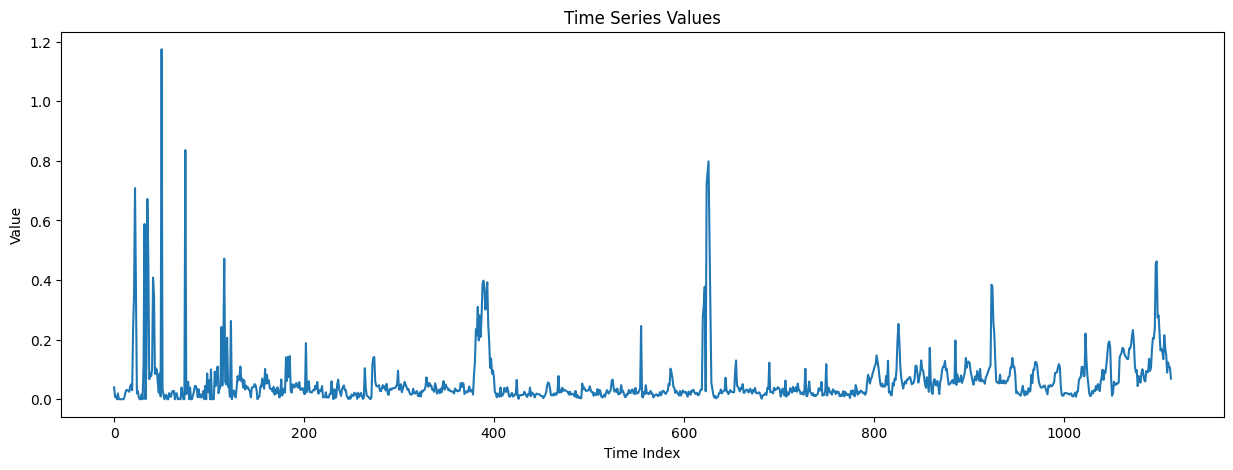

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(sample2["Value"])

plt.title("Time Series Values")
plt.xlabel("Time Index")
plt.ylabel("Value")

plt.show()

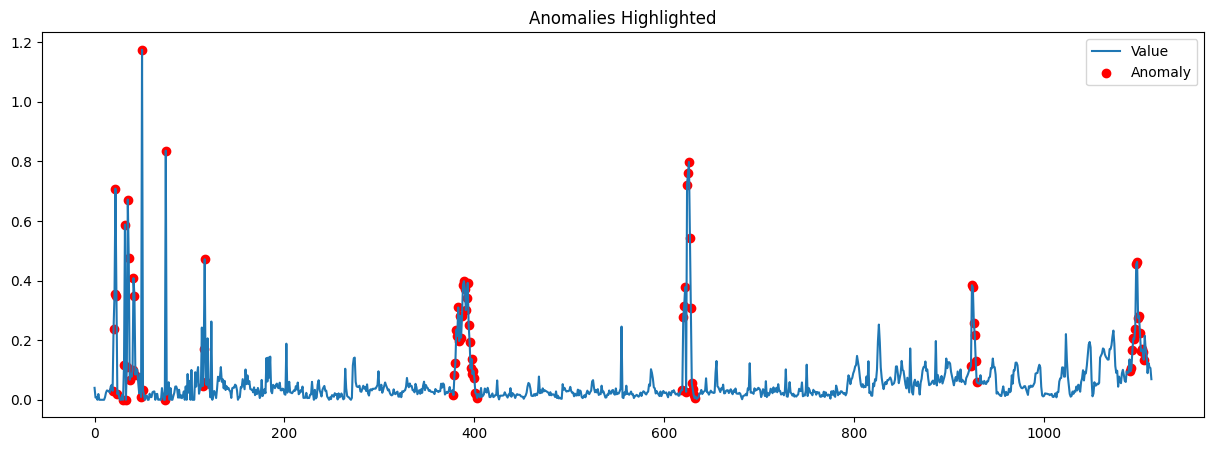

In [18]:
plt.figure(figsize=(15,5))

plt.plot(sample2["Value"], label="Value")

anomalies = sample2[sample2["Label"] == 1]

plt.scatter(
    anomalies.index,
    anomalies["Value"],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Anomalies Highlighted")

plt.show()

In [19]:
import os
import pandas as pd

data_folder = "/content/datasetA/cloud-monitoring-dataset-master/data"

for root, dirs, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".csv"):
            path = os.path.join(root, file)

            temp = pd.read_csv(path)

            anomaly_count = temp["Label"].sum()

            print(file, "->", anomaly_count)

mongo-03.csv -> 1092
mongo-02.csv -> 6
mongo-04.csv -> 0
mongo-01.csv -> 0
purchase-05.csv -> 82
purchase-02.csv -> 37
purchase-03.csv -> 11
purchase-04.csv -> 27
purchase-06.csv -> 14
purchase-01.csv -> 0
outbound-22.csv -> 11
outbound-05.csv -> 36
outbound-19.csv -> 38
outbound-14.csv -> 3
outbound-10.csv -> 15
outbound-11.csv -> 42
outbound-08.csv -> 28
outbound-23.csv -> 15
outbound-09.csv -> 15
outbound-01.csv -> 8
outbound-03.csv -> 14
outbound-02.csv -> 32
outbound-06.csv -> 3
outbound-20.csv -> 43
outbound-21.csv -> 43
outbound-12.csv -> 68
outbound-13.csv -> 3
outbound-15.csv -> 38
outbound-16.csv -> 0
outbound-07.csv -> 26
outbound-17.csv -> 3
outbound-18.csv -> 38
outbound-04.csv -> 31
app1-02.csv -> 94
app1-01.csv -> 40
app1-03.csv -> 166
app1-05.csv -> 73
app1-06.csv -> 115
app1-09.csv -> 7
app1-07.csv -> 7
app1-08.csv -> 65
app1-04.csv -> 181
api-01.csv -> 120
app2-03.csv -> 17
app2-08.csv -> 15
app2-07.csv -> 134
app2-02.csv -> 28
app2-04.csv -> 14
app2-06.csv -> 51
app2